## ViT

In [2]:
import torch
from PIL import Image
from torchvision.models import vision_transformer

from zennit.image import imgify
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from lxt.efficient import monkey_patch, monkey_patch_zennit

monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward


In [3]:
from io import BytesIO
import requests

def get_vit_imagenet(device="cuda"):
    """
    Load a pre-trained Vision Transformer (ViT) model with ImageNet weights.

    Parameters:
    device (str): Device to load the model on ('cuda' or 'cpu')

    Returns:
    tuple: (model, weights) - The ViT model and its pre-trained weights
    """
    weights =vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval()
    model.to(device)

    # Deactivate gradients on parameters to save memory
    for param in model.parameters():
        param.requires_grad = False

    return model, weights

# Load the pre-trained ViT model
model_vit, weights = get_vit_imagenet()

# Load and preprocess the input image
image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")
input_tensor = weights.transforms()(image).unsqueeze(0).to("cuda")

In [4]:
image.size

(2048, 1365)

In [5]:
model_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [6]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [7]:
# Define rules for the Conv2d and Linear layers using 'zennit'
conv_gamma = 100
lin_gamma = 0.05
# LayerMapComposite maps specific layer types to specific LRP rule implementations
zennit_comp = LayerMapComposite([
    (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
    (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
])

# Register the composite rules with the model_vit
zennit_comp.register(model_vit)

# Forward pass with gradient tracking enabled
y = model_vit(input_tensor.requires_grad_())

# Get the top 5 predictions
_, top5_classes = torch.topk(y, 5, dim=1)
top5_classes = top5_classes.squeeze(0).tolist()

# Get the class labels
labels = weights.meta["categories"]
top5_labels = [labels[class_idx] for class_idx in top5_classes]

# Print the top 5 predictions and their labels
for i, class_idx in enumerate(top5_classes):
    print(f'Top {i+1} predicted class: {class_idx}, label: {top5_labels[i]}')

# Backward pass for the highest probability class
# This initiates the LRP computation through the network
y[0, top5_classes[0]].backward()

# Remove the registered composite to prevent interference in future iterations
zennit_comp.remove()

# Calculate the relevance by computing Input*Gradient
# This is the final step of LRP to get the pixel-wise explanation
heatmap = (input_tensor * input_tensor.grad).sum(1)

# Normalize relevance between [-1, 1] for plotting
heatmap = heatmap / abs(heatmap).max()

Top 1 predicted class: 176, label: Saluki
Top 2 predicted class: 250, label: Siberian husky
Top 3 predicted class: 207, label: golden retriever
Top 4 predicted class: 248, label: Eskimo dog
Top 5 predicted class: 208, label: Labrador retriever


In [8]:
heatmap.shape

torch.Size([1, 224, 224])

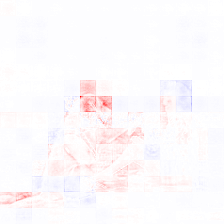

In [9]:
imgify(heatmap.detach().cpu().numpy(), vmin=-1, vmax=1)

## Qwen 3

In [1]:
import torch
from transformers import AutoTokenizer
from transformers.models.qwen3 import modeling_qwen3
from transformers import BitsAndBytesConfig

from lxt.efficient import monkey_patch
from lxt.utils import pdf_heatmap, clean_tokens

# modify the Qwen3 module to compute LRP in the backward pass
monkey_patch(modeling_qwen3, verbose=True)

# optional 4bit quantization 
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

path = 'Qwen/Qwen3-1.7B'
model = modeling_qwen3.Qwen3ForCausalLM.from_pretrained(path,
                                                        device_map='auto',
                                                        dtype=torch.bfloat16,
                                                        quantization_config=quantization_config)


tokenizer = AutoTokenizer.from_pretrained(path)

prompt = """Context: Mount Everest attracts many climbers, including highly experienced mountaineers. There are two main climbing routes, one approaching the summit from the southeast in Nepal (known as the standard route) and the other from the north in Tibet. While not posing substantial technical climbing challenges on the standard route, Everest presents dangers such as altitude sickness, weather, and wind, as well as hazards from avalanches and the Khumbu Icefall. As of November 2022, 310 people have died on Everest. Over 200 bodies remain on the mountain and have not been removed due to the dangerous conditions. The first recorded efforts to reach Everest's summit were made by British mountaineers. As Nepal did not allow foreigners to enter the country at the time, the British made several attempts on the north ridge route from the Tibetan side. After the first reconnaissance expedition by the British in 1921 reached 7,000 m (22,970 ft) on the North Col, the 1922 expedition pushed the north ridge route up to 8,320 m (27,300 ft), marking the first time a human had climbed above 8,000 m (26,247 ft). The 1924 expedition resulted in one of the greatest mysteries on Everest to this day: George Mallory and Andrew Irvine made a final summit attempt on 8 June but never returned, sparking debate as to whether they were the first to reach the top. Tenzing Norgay and Edmund Hillary made the first documented ascent of Everest in 1953, using the southeast ridge route. Norgay had reached 8,595 m (28,199 ft) the previous year as a member of the 1952 Swiss expedition. The Chinese mountaineering team of Wang Fuzhou, Gonpo, and Qu Yinhua made the first reported ascent of the peak from the north ridge on 25 May 1960. \
Question: How high did they climb in 1922? According to the text, the 1922 expedition reached 8,"""

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(model.device)
input_ids = inputs.input_ids


/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched Qwen3MLP
Patched Qwen3RMSNorm
Patched Dropout
Patched transformers.models.qwen3.modeling_qwen3


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]


In [2]:

attention_mask = inputs.attention_mask

with torch.no_grad():
    generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask)
# tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]


In [3]:
generated_ids.shape

torch.Size([1, 476])

In [ ]:

gen_ids = generated_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

tokenizer.batch_decode(gen_ids, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'320 m (27,300 ft). The answer is...?\nA)'

In [6]:
L_gen = gen_ids.size(1)

# positions whose logits predict each generated token
indices = torch.arange(
    ctx_len - 1,
    ctx_len - 1 + L_gen,
    device=model.device
)  # shape [L_gen]


In [9]:
L_gen = gen_ids.size(1)
L_gen

20

In [12]:
# # optional gradient checkpointing to save memory (2x forward pass)
# model.train()
# model.gradient_checkpointing_enable()

# deactive gradients on parameters to save memory
for param in model.parameters():
    param.requires_grad = False


# get input embeddings so that we can compute gradients w.r.t. input embeddings
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).input_ids.to(model.device)
# input_embeds = model.get_input_embeddings()(input_ids)
input_embeds = model.get_input_embeddings()(generated_ids)

# inference and get the maximum logit at the last position (we can also explain other tokens)
output_logits = model(inputs_embeds=input_embeds.requires_grad_(), use_cache=False).logits


In [13]:
output_logits.shape

torch.Size([1, 476, 151936])

In [14]:
selected_logits = output_logits[0, indices, gen_ids[0]]   # [L_gen]

selected_logits.backward(torch.ones_like(selected_logits))
# equivalently: selected_logits.sum().backward()


In [35]:
# max_logits, max_indices = torch.max(output_logits[0, -1, :], dim=-1)

# # Backward pass (the relevance is initialized with the value of max_logits)
# # This initiates the LRP computation through the network
# max_logits.backward()

# obtain relevance by computing Input * Gradient
relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0] # cast to float32 before summation for higher precision

# normalize relevance between [-1, 1] for plotting
#relevance = relevance / relevance.abs().max()

In [16]:
# remove special characters from token strings and plot the heatmap
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens = clean_tokens(tokens)

# pdf_heatmap(tokens, relevance, path='qwen3_1.7B_heatmap.pdf', backend='xelatex') # backend='xelatex' supports more characters

# # plot again without first token, because it receives large relevance values overshadowing the rest
# pdf_heatmap(tokens[1:], relevance[1:] / relevance[1:].max(), path='qwen3_1.7B_heatmap_wo_first.pdf', backend='xelatex')

In [36]:
prompt_relevance = relevance[:ctx_len]
prompt_tokens = tokenizer.convert_ids_to_tokens(generated_ids[0, :ctx_len])
prompt_tokens = clean_tokens(prompt_tokens)



In [37]:
import numpy as np
import matplotlib

def _apply_colormap(relevance, cmap_name="bwr"):
    """
    Map a scalar relevance in [-1, 1] to an RGB triplet in [0, 1].
    """
    # normalize from [-1, 1] to [0, 1]
    v = (relevance + 1.0) / 2.0
    v = np.clip(v, 0.0, 1.0)

    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    r, g, b, _ = cmap(v)
    return r, g, b


def _escape_html(text: str) -> str:
    return (
        text.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
    )

def _generate_html(words, relevances, cmap="bwr"):
    """
    Generate HTML code for a sentence with colored words based on their relevances.
    """
    html = []
    html.append("<!DOCTYPE html>")
    html.append("<html>")
    html.append("<head>")
    html.append('<meta charset="utf-8">')
    html.append("<style>")
    html.append("""
    body {
        font-family: sans-serif;
        max-width: 900px;
        line-height: 1.6;
        padding: 1rem;
    }
    .token {
        padding: 2px 3px;
        margin: 1px 1px;
        display: inline-block;
        font-family: monospace;
        border-radius: 2px;
    }
    """)
    html.append("</style>")
    html.append("</head>")
    html.append("<body>")

    for word, relevance in zip(words, relevances):
        r, g, b = _apply_colormap(float(relevance), cmap)
        R, G, B = int(r * 255), int(g * 255), int(b * 255)

        word_html = _escape_html(word)
        html.append(
            f'<span class="token" '
            f'style="background-color: rgb({R},{G},{B});">'
            f'{word_html}</span>'
        )

    html.append("</body>")
    html.append("</html>")

    return "\n".join(html)


In [38]:
def html_heatmap(words, relevances, path="heatmap.html", cmap="bwr"):
    """
    Write an HTML file with colored tokens according to relevance.
    No LaTeX, no external dependencies beyond matplotlib (for colormap).
    """
    html_code = _generate_html(words, relevances, cmap=cmap)

    with open(path, "w", encoding="utf-8") as f:
        f.write(html_code)

    print(f"Saved HTML heatmap to: {path}")
    return path


In [39]:
from IPython.display import HTML, display


# html_heatmap(prompt_tokens, prompt_relevance,
#             path='qwen3_1.7B_prediction_heatmap.html')
html_code = _generate_html(prompt_tokens, prompt_relevance, cmap="bwr")
display(HTML(html_code))

## Captum LLM

In [1]:
from huggingface_hub import login
login()

In [1]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        #device_map="auto",
        max_memory={"cuda:0": "20GiB", "cpu": "48GiB"},
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [3]:
torch.cuda.empty_cache()

In [4]:
from abc import abstractmethod
from typing import Union
from torch import nn

class HF_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                image_grid_thw):

        # Vision embeddings
        image_embeds = model.get_image_features(pixel_values,
                                                image_grid_thw=image_grid_thw)
        
        image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
        image_mask, _ = model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_embeds
        )
        inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"]
        del outputs
        return logits


    # --------- device helpers ---------

    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "HF_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


In [5]:
from captum.attr import (
    LLMGradientAttribution, 
    TextTokenInput,
    InputXGradient,
    TokenReferenceBase,
    visualization
)

In [6]:
hf_model = HF_Wrapper(model, processor)

In [20]:
ig.model

AttributeError: 'InputXGradient' object has no attribute 'model'

In [7]:
from PIL import Image
import requests
from io import BytesIO

def get_inputs(processor, dtype=torch.bfloat16):
    image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
    image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                # {"type": "text", "text": "Describe the main scene and the object being pointed at."},
                {"type": "text", "text": "What is the color of the dog ?"},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

     # ---- Convert everything that can be bf16 into bf16 ----
    if dtype is not None:
        for k in inputs:
            if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
                inputs[k] = inputs[k].to(dtype=dtype)


    return inputs, image


In [8]:
inputs, image = get_inputs(processor)

In [9]:
inputs = inputs.to(model.device)

In [10]:
def get_target(inputs, model):
    inputs = inputs.to(model.device)
    model.eval()
    with torch.no_grad():

        gen_ids = model.generate(**inputs,
                                max_new_tokens=32,
                                use_cache=False)

    return gen_ids


In [11]:
gen_ids = get_target(inputs, model)

In [12]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)


In [13]:
target_tokens = generated_ids_trimmed[0]

In [14]:

text = hf_model.processor.batch_decode(
                    target_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False
                )

In [15]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [16]:
def get_attributions(inputs, hf_model, attr, target_tokens, plot=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    text_embeds = hf_model.text_embeddings_layer(input_ids).clone().detach()

    captum_forward = (text_embeds, pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids, image_grid_thw)

    # Make a forward and predictions
    captum_args = captum_forward + captum_add_forward

    # logits = hf_model(*captum_args)
    # pred, idx = torch.max(logits[0, -1, :], dim=-1)

    text = hf_model.processor.batch_decode(
                        target_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False
                    )
    
    baselines = None
    use_baselines = False
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=hf_model.device).unsqueeze(0)
        reference_embeds = hf_model.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)
    
    # Get attributions
    if use_baselines:
        attributions = attr.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=1,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr.attribute(inputs=captum_forward,
                                    target=1,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    # Visualize text attributions
    text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
    text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm



    

    if plot:
        # Visualize text attributions
        # vis_data_records = [visualization.VisualizationDataRecord(
        #                     text_attr,
        #                     pred[0].item(),
        #                     model.config.id2label[idx.item()],
        #                     model.config.id2label[idx.item()],
        #                     target_tokens,
        #                     attributions[0].sum(),       
        #                     text.split(),
        #                     0.0)]
        # visualization.visualize_text(vis_data_records)

        # visualize image attributions
        original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

        # visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
        #                                             ["original_image", "heat_map"], ["all", "all"], 
        #                                             titles=["Original Image", "Attribution Magnitude"],
        #                                             cmap=default_cmap,
        #                                             show_colorbar=True)
    
    return attributions

In [17]:
import sys, gc, torch

gc.collect()
torch.cuda.empty_cache()

In [18]:
torch.cuda.empty_cache()

In [ ]:
ig = InputXGradient(hf_model)

try:
    attributions = get_attributions(inputs, hf_model, ig, target_tokens, plot=False)
except Exception as e:
    print(e)
    for name in ["inputs"]:
        if name in locals():
            del locals()[name]
    gc.collect()
    torch.cuda.empty_cache()

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


In [14]:
baselines = None
use_baselines = False
if use_baselines:
    # Baselines
    token_reference = TokenReferenceBase(reference_token_idx=processor.tokenizer.pad_token_id)
    # generate reference for each sample
    reference_ids = token_reference.generate_reference(
                            input_ids.shape[-1],
                            device=hf_model.device).unsqueeze(0)
    reference_embeds = hf_model.text_embeddings_layer(reference_ids)
    baselines = (reference_embeds, pixel_values * 0.0)

In [ ]:
captum_forward = (text_embeds, pixel_values.requires_grad_())
captum_add_forward = (attention_mask, image_grid_thw)

# Make a forward and predictions
captum_args = captum_forward + captum_add_forward
#logits = hf_model(*captum_args)
#pred, idx = logits.max(dim=1)




/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


AssertionError: Target not provided when necessary, cannot take gradient with respect to multiple outputs.

In [22]:
# Get attributions
#if use_baselines:
attributions = ig.attribute(inputs=captum_forward,
                            #baselines=baselines,
                            target=idx,
                            additional_forward_args=captum_add_forward,
                            #n_steps=10
                            )

AssertionError: Target not provided when necessary, cannot take gradient with respect to multiple outputs.

In [ ]:
from typing import List, Optional, Dict, Any
from copy import copy

from captum._utils.typing import TokenizerLike
from captum.attr._utils.attribution import Attribution
import torch
from torch import nn, Tensor
from captum.attr._core.llm_attr import BaseLLMAttribution
from captum.attr._utils.attribution import GradientAttribution


import torch.nn.functional as F


class CaptumLLMAttribution(BaseLLMAttribution):
    def __init__(self, attr_method: GradientAttribution, tokenizer: TokenizerLike) -> None:
        super().__init__(attr_method, tokenizer)

        # shallow copy is enough to avoid modifying original instance
        self.attr_method: GradientAttribution = copy(attr_method)
        self.attr_method.forward_func = CaptumLLMForwardFunc(self)

    def attribute(self,
                  inpts,
                  target: Union[str, List[str], torch.Tensor],
                    use_baselines=True,
                    attr_kwargs: Optional[Dict[str, Any]] = None,
                    ):

        if isinstance(target, torch.Tensor):
            # Move the target to the good device
            target_tokens = target.clone().detach().to(self.device)
        
        else: # isinstance(target, list):
            # Encode the target using the preprocessor
            target_tokens = self.tokenizer(target, return_tensors="pt", add_special_tokens=True).to(self.device)
        


        inpts.to(self.device)
        input_ids = inpts.input_ids
        attention_mask = inpts.attention_mask


        # Call the attrubition method
        attr_list = []
        n_output_tokens = target_tokens.size(0)

        # Get the embeddings
        input_embeds = self.attr_method.model.get_inputs_embeddings(input_ids).clone().detach()

        baselines = None
        # if use_baselines:
        #     # Baselines
        #     token_reference = TokenReferenceBase(reference_token_idx=tokenizer.pad_token_id)
        #     # generate reference for each sample
        #     reference_ids = token_reference.generate_reference(
        #                             input_ids.shape[-1],
        #                             device=model_wrapper.device).unsqueeze(0)
        #     reference_embeds = model_wrapper.vilt.embeddings.text_embeddings.word_embeddings(reference_ids)
        #     baselines = (reference_embeds,)

        for cur_target_idx in range(n_output_tokens):
            
            captum_forward = (input_embeds,)
            captum_add_forward = (attention_mask, target_tokens, cur_target_idx)


            # Get attributions
            if use_baselines:
                attr = self.attr_method.attribute(inputs=captum_forward,
                                            baselines=baselines,
                                            additional_forward_args=captum_add_forward,
                                            **attr_kwargs,
                                            )  
            else:
                attr = self.attr_method.attribute(inputs=captum_forward,
                                            additional_forward_args=captum_add_forward,
                                            **attr_kwargs,
                                            )


            attr = attr.detach()

            # will have the attr for previous output tokens
            # cut to shape(batch_size, inp_len, emb_dim)
            if cur_target_idx:
                attr = attr[:, :-cur_target_idx]

            # the author of IG uses sum
            # https://github.com/ankurtaly/Integrated-Gradients/blob/master/BertModel/bert_model_utils.py#L350
            attr = attr.sum(-1)

            attr_list.append(attr)

        # assume inp batch only has one instance
        # to shape(n_output_token, ...)
        attr = torch.cat(attr_list, dim=0)

        # # grad attr method do not care the length of features in interpretable format
        # # it attributes to all the elements of the output of the specified layer
        # # so we need special handling for the inp type which don't care all the elements
        # if isinstance(inp, TextTokenInput) and inp.itp_mask is not None:
        #     itp_mask = inp.itp_mask.to(attr.device)
        #     itp_mask = itp_mask.expand_as(attr)
        #     attr = attr[itp_mask].view(attr.size(0), -1)

        # for all the gradient methods we support in this class
        # the seq attr is the sum of all the token attr if the attr_target is log_prob,
        # shape(n_input_features)
        seq_attr = attr.sum(0)
        return seq_attr



class CaptumLLMForwardFunc(nn.Module):
    """
    Forward wrapper for Captum, analogous to GradientForwardFunc.

    Inputs:
        text_embeds:    (B, L_in, D)  - embeddings for the *input* tokens
        attention_mask: (B, L_in)     - attention mask for input tokens
        target_tokens:  (L_out,)      - 1D tensor of target token ids
        cur_target_idx: int           - index of current target token

    Optionally:
        pixel_values, pixel_mask, token_type_ids for VLMs (e.g. ViLT).
    """

    def __init__(self, attr: CaptumLLMAttribution) -> None:
        super().__init__()
        self.attr = attr
        self.model = attr.model  # e.g. an HF_Wrapper

    def forward(
        self,
        text_embeds: torch.Tensor,
        attention_mask: torch.Tensor,
        target_tokens: torch.Tensor,
        cur_target_idx: int,
    ) -> torch.Tensor:
        """
        Returns:
            token_log_probs: (B,) log p(target_tokens[cur_target_idx] | input, prefix)
        """
        device = self.model.device
        B, _, _ = text_embeds.shape

        # target_tokens = target_tokens.to(device)

        # --- build teacher-forced prefix for output tokens in embedding space ---
        if cur_target_idx > 0:
            # Prefix token ids: [t_0, ..., t_{k-1}], shape (k,)
            # replicate for all batch samples: (B, k)
            prefix_ids = target_tokens[:cur_target_idx].unsqueeze(0).expand(B, -1).to(device)

            # convert prefix ids to embeddings via the model's text embedding layer
            prefix_embeds = self.model.text_embeddings_layer(prefix_ids)  # (B, k, D)

            # concat along sequence dimension: input tokens + prefix tokens
            new_text_embeds = torch.cat([text_embeds, prefix_embeds], dim=1)  # (B, L_in + k, D)

            # attention mask for prefix (all ones)
            prefix_mask = torch.ones_like(
                prefix_embeds, dtype=attention_mask.dtype, device=device
            )
            new_attention_mask = torch.cat([attention_mask, prefix_mask], dim=1)  # (B, L_in + k)
        else:
            new_text_embeds = text_embeds
            new_attention_mask = attention_mask

        # --- forward through wrapped model ---
        logits = self.model(
            text_embeds=new_text_embeds,
            attention_mask=new_attention_mask,
        )  # expected shape: (B, L_total, vocab_size)

        # we only care about logits at the *last* position (next-token prediction)
        last_logits = logits[:, -1, :]  # (B, vocab_size)
        log_probs = F.log_softmax(last_logits, dim=-1)

        # scalar target token id
        target_token_id = target_tokens[cur_target_idx]
        # pick log-probability of that token for each sample
        token_log_probs = log_probs[..., target_token_id]  # (B,)

        return token_log_probs



In [ ]:
from typing import List, Union, Dict, Any, Optional
import torch
from torch import Tensor
from captum.attr import TokenReferenceBase  # if you use baselines
# from captum.attr import LayerIntegratedGradients  # for construction elsewhere


def captum_llm_attribution(
    inpts,                         # HF BatchEncoding (input_ids, attention_mask, ...)
    target: Union[str, List[str], torch.Tensor],
    model_wrapper,                 # instance of HF_Wrapper (or compatible)
    tokenizer,
    attr_hf,                       # Captum attribution object (e.g. LayerIntegratedGradients)
    use_baselines: bool = True,
    attr_kwargs: Optional[Dict[str, Any]] = None,
    pixel_values: Optional[Tensor] = None,
    pixel_mask: Optional[Tensor] = None,
    token_type_ids: Optional[Tensor] = None,
) -> Dict[str, Any]:
    """
    Compute token- and sequence-level attributions for a given LLM/VLM target.

    Args:
        inpts: HF tokenizer outputs (e.g. tokenizer(prompt, return_tensors="pt")).
        target: target text (str or list of str) or tensor of token ids.
        model_wrapper: your HF_Wrapper-like module with .text_embeddings_layer and .device.
        tokenizer: HF tokenizer.
        attr_hf: Captum attribution instance, whose forward_func should be CaptumLLMForwardFunc(model_wrapper).
        use_baselines: if True, use pad-token embeddings as baseline.
        attr_kwargs: extra kwargs passed to attr_hf.attribute (e.g. n_steps).
        pixel_values, pixel_mask, token_type_ids: for VLM models like ViLT.

    Returns:
        {
          "seq_attr":     Tensor (n_input_tokens,),
          "token_attr":   Tensor (n_output_tokens, n_input_tokens),
          "input_tokens": List[str],
          "output_tokens":List[str],
        }
    """
    if attr_kwargs is None:
        attr_kwargs = {}

    device = model_wrapper.device

    # --- 1. Prepare input tensors on the right device ---
    # HF BatchEncoding supports .to(device), but be sure to reassign.
    inpts = inpts.to(device)
    input_ids: Tensor = inpts["input_ids"]         # (B, L_in)
    attention_mask: Tensor = inpts["attention_mask"]  # (B, L_in)
    B, L_in = input_ids.shape
    assert B == 1, "Current implementation assumes batch size 1 for simplicity."

    # --- 2. Prepare target tokens as 1D tensor (L_out,) ---
    if isinstance(target, torch.Tensor):
        # assume shape (L_out,)
        target_tokens = target.to(device)
    else:
        # treat as text -> tokenize
        # you may want add_special_tokens=False depending on your setup
        enc = tokenizer(
            target,
            return_tensors="pt",
            add_special_tokens=True,
        )
        # collapse batch dimension, assume single sequence
        target_tokens = enc["input_ids"].view(-1).to(device)  # (L_out,)

    # --- 3. Get input embeddings from the model's embedding layer ---
    text_embeds: Tensor = model_wrapper.text_embeddings_layer(input_ids)  # (B, L_in, D)

    # --- 4. Baselines in embedding space (optional) ---
    baselines = None
    if use_baselines:
        token_reference = TokenReferenceBase(reference_token_idx=tokenizer.pad_token_id)
        # generate reference ids of length L_in
        reference_ids = token_reference.generate_reference(
            L_in, device=device
        ).unsqueeze(0)  # (1, L_in)
        baseline_embeds = model_wrapper.text_embeddings_layer(reference_ids)  # (1, L_in, D)
        baselines = baseline_embeds

    # --- 5. Loop over each target token, à la LLMGradientAttribution.attribute ---
    attr_list = []
    n_output_tokens = target_tokens.size(0)

    for cur_target_idx in range(n_output_tokens):
        # For cur_target_idx, forward_func returns log p(t_k | input, t_<k)
        if use_baselines:
            token_attr = attr_hf.attribute(
                inputs=text_embeds,
                baselines=baselines,
                additional_forward_args=(
                    attention_mask,
                    target_tokens,
                    cur_target_idx,
                    pixel_values,
                    pixel_mask,
                    token_type_ids,
                ),
                **attr_kwargs,
            )
        else:
            token_attr = attr_hf.attribute(
                inputs=text_embeds,
                additional_forward_args=(
                    attention_mask,
                    target_tokens,
                    cur_target_idx,
                    pixel_values,
                    pixel_mask,
                    token_type_ids,
                ),
                **attr_kwargs,
            )

        # token_attr shape for a layer method on embeddings:
        #   (B, L_in + prefix_len, D) or (B, L_in, D) depending on how hooks are defined.
        token_attr = token_attr.detach()

        # We only care about attribution to the *input* tokens, not the appended prefix tokens.
        # Since our inputs to Captum are only the input embeddings (no prefix),
        # we slice to the first L_in positions.
        token_attr = token_attr[:, :L_in, :]  # (B, L_in, D)

        # collapse embedding dimension → scalar per input token
        token_attr = token_attr.sum(dim=-1)   # (B, L_in)

        attr_list.append(token_attr)

    # --- 6. Stack across output tokens ---
    # (n_output_tokens, B, L_in) → (n_output_tokens, L_in) since B=1
    token_attr = torch.cat(attr_list, dim=0)  # (n_output_tokens, L_in)

    # --- 7. Sequence-level attribution: sum over all output tokens ---
    seq_attr = token_attr.sum(dim=0)          # (L_in,)

    # --- 8. Human-readable tokens ---
    input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
    output_tokens = tokenizer.convert_ids_to_tokens(target_tokens.tolist())

    return {
        "seq_attr": seq_attr,           # (L_in,)
        "token_attr": token_attr,       # (n_output_tokens, L_in)
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
    }


In [ ]:
from copy import copy
from typing import Any, Dict, List, Optional, Union, cast
import torch
from torch import Tensor
from captum.attr import GradientAttribution
from captum.attr._utils.interpretable_input import InterpretableInput

import torch.nn as nn
import torch.nn.functional as F

class VisionTextInput(InterpretableInput):
    # what you store
    input_ids: Tensor
    attention_mask: Tensor
    pixel_values: Optional[Tensor] = None
    image_grid_thw: Optional[Tensor] = None  # Qwen2-VL-style
    model: Optional[Any] = None              # for embed_tokens if needed

    def to_tensor(self) -> Tensor:
        """
        Return the tensor Captum will perturb – here, text embeddings.
        """
        assert self.model is not None, "Model must be set to build embeddings."
        # (B, L_text, D)
        text_embeds = self.model.model.embed_tokens(self.input_ids)
        return text_embeds

    def to_model_input(self, perturbed_tensor: Tensor) -> Dict[str, Any]:
        """
        Build the dict of inputs for the HF model, using the perturbed text embeddings
        and the original image inputs.
        For Qwen2-VL, we need to fuse image embeddings into inputs_embeds.
        """
        # 1) Start from token embeddings
        inputs_embeds = perturbed_tensor  # (B, L_text, D)

        # 2) If you want to follow Qwen2-VL's manual fusion pattern:
        #    (code adapted from HF issue / docs) 
        if self.pixel_values is not None:
            pixel_values = self.pixel_values
            model = self.model

            pixel_values = pixel_values.type(model.visual.get_dtype())
            image_embeds = model.visual(pixel_values, grid_thw=self.image_grid_thw)
            # locate <image> tokens
            image_token_id = model.config.image_token_id
            n_image_tokens = (self.input_ids == image_token_id).sum().item()
            n_image_features = image_embeds.shape[0]
            if n_image_tokens != n_image_features:
                raise ValueError(
                    f"Image features and image tokens do not match: "
                    f"tokens: {n_image_tokens}, features {n_image_features}"
                )

            image_mask = (
                (self.input_ids == image_token_id)
                .unsqueeze(-1)
                .expand_as(inputs_embeds)
                .to(inputs_embeds.device)
            )
            image_embeds = image_embeds.to(inputs_embeds.device, inputs_embeds.dtype)
            inputs_embeds = inputs_embeds.masked_scatter(image_mask, image_embeds)

        # 3) Return the dict HF model expects
        return {
            "inputs_embeds": inputs_embeds,
            "attention_mask": self.attention_mask,
            "pixel_values": self.pixel_values,
            "image_grid_thw": self.image_grid_thw,
        }

class VLLMGradientForwardFunc(nn.Module):
    """
    Like Captum's GradientForwardFunc, but aware of images / Qwen-VL.

    It:
    - takes a perturbed embedding tensor (text part),
    - uses `inp.to_model_input(...)` to build HF model inputs (with image),
    - appends previous target tokens (teacher forcing),
    - forwards through the model,
    - returns log p(target_tokens[cur_target_idx]).
    """

    def __init__(self, attr_wrapper: "VLLMGradientAttribution"):
        super().__init__()
        self.attr = attr_wrapper
        self.model = attr_wrapper.model  # HF model

    def forward(
        self,
        inputs: Dict[str, Tensor],
        target_tokens: Tensor,   # 1D [L_out]
        cur_target_idx: int,     # int
    ) -> Tensor:
        
        # 1) Build base inputs from perturbed text embeddings + image
        inputs_embeds = inputs["inputs_embeds"]   # (B, L_in, D)
        attention_mask = inputs["attention_mask"]
        pixel_values = inputs.get("pixel_values", None)
        image_grid_thw = inputs.get("image_grid_thw", None)

        B, L_in, D = inputs_embeds.shape
        device = inputs_embeds.device
        target_tokens = target_tokens.to(device)

        # 2) Teacher forcing: append previous target tokens as text embeddings
        if cur_target_idx > 0:
            prefix_ids = target_tokens[:cur_target_idx].unsqueeze(0).expand(B, -1).to(self.attr.device)
            prefix_embeds = self.model.model.embed_tokens(prefix_ids)  # (B, k, D)

            inputs_embeds = torch.cat([inputs_embeds, prefix_embeds], dim=1)  # (B, L_in+k, D)

            prefix_mask = torch.ones(
                (B, cur_target_idx),
                dtype=attention_mask.dtype,
                device=device,
            )
            attention_mask = torch.cat([attention_mask, prefix_mask], dim=1)
        # else: keep as is

        # 3) Forward through Qwen-VL (or any VLLM) using embeds
        outputs = self.model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            image_grid_thw=image_grid_thw,
        )
        logits = outputs.logits  # (B, seq_len, vocab_size)

        # 4) Log prob of current target token at last step
        last_logits = logits[:, -1, :]
        log_probs = F.log_softmax(last_logits, dim=-1)

        target_token_id = target_tokens[cur_target_idx]
        token_log_probs = log_probs[..., target_token_id]  # (B,)

        return token_log_probs


class VLLMGradientAttribution:
    """
    Gradient-based attribution wrapper for VLMs (e.g., Qwen-VL),
    inspired by captum.attr.LLMGradientAttribution.
    """

    SUPPORTED_METHODS = (...)          # e.g. (LayerIntegratedGradients, ...)
    SUPPORTED_INPUTS = (VisionTextInput,)

    def __init__(self, attr_method: GradientAttribution, processor) -> None:
        self.processor = processor
        # shallow copy to not modify original
        self.attr_method: GradientAttribution = copy(attr_method)
        # HF model is usually attr_method.forward_func.model, but
        # you may want to pass it in separately.
        self.model = attr_method.forward_func  # or inject explicitly
        self.device = next(self.model.parameters()).device

        # replace forward_func with our multimodal version
        self.attr_method.forward_func = VLLMGradientForwardFunc(self)

    def attribute(
        self,
        inp: VisionTextInput,
        target_tokens: Union[Tensor, None] = None,
        skip_tokens: Optional[Union[List[int], List[str]]] = None,
        gen_args: Optional[Dict[str, Any]] = None,
        **kwargs: Any,
    ):
        # basically a copy of LLMGradientAttribution.attribute, but with VisionTextInput


        attr_inp = inp.to_tensor().to(self.device)  # (B, L_in, D)

        attr_list = []
        for cur_target_idx, _ in enumerate(target_tokens):
            # per-token gradient attribution w.r.t. log p(t_k)
            attr = self.attr_method.attribute(
                attr_inp,
                additional_forward_args=(
                    inp,
                    target_tokens,
                    cur_target_idx,
                ),
                **kwargs,
            ).detach()
            attr = cast(Tensor, attr)  # (B, L_in, D) or similar

            # For VLM we’re attributing only to *input* tokens, so no slicing here,
            # because our forward only ever appends prefix tokens in embedding space,
            # not to attr_inp itself.
            # If you modify attr_inp to contain prefix tokens, slice as in LLMGradientAttribution.

            # sum over embedding dim → scalar per input token
            attr = attr.sum(-1)  # (B, L_in)

            attr_list.append(attr)

        # stack over output tokens
        token_attr = torch.cat(attr_list, dim=0)  # (L_out, L_in)

        # sequence-level attribution (sum over output tokens)
        seq_attr = token_attr.sum(0)  # (L_in,)
 
        return {
            "seq_attr": seq_attr,
            "token_attr": token_attr,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
        }


In [ ]:
class LLMGradientAttribution(BaseLLMAttribution):
    """
    Attribution class for large language models. It wraps a gradient-based
    attribution algorthm to produce commonly interested attribution
    results for the use case of text generation.
    The wrapped instance will calculate attribution in the
    same way as configured in the original attribution algorthm,
    with respect to the log probabilities of each
    generated token and the whole sequence. It will provide a
    new "attribute" function which accepts text-based inputs
    and returns LLMAttributionResult
    """


    def __init__(
        self,
        attr_method: GradientAttribution,
        tokenizer: TokenizerLike,
    ) -> None:
        """
        Args:
            attr_method (Attribution): instance of a supported perturbation attribution
                    class created with the llm model that follows huggingface style
                    interface convention
            tokenizer (Tokenizer): tokenizer of the llm model used in the attr_method
        """
        super().__init__(attr_method, tokenizer)

        # shallow copy is enough to avoid modifying original instance
        self.attr_method: GradientAttribution = copy(attr_method)
        self.attr_method.forward_func = GradientForwardFunc(self)

    def attribute(
        self,
        inp: InterpretableInput,
        target: Union[str, torch.Tensor, None] = None,
        skip_tokens: Union[List[int], List[str], None] = None,
        gen_args: Optional[Dict[str, Any]] = None,
        **kwargs: Any,
    ) -> LLMAttributionResult:
        """
        Args:
            inp (InterpretableInput): input prompt for which attributions are computed
            target (str or Tensor, optional): target response with respect to
                    which attributions are computed. If None, it uses the model
                    to generate the target based on the input and gen_args.
                    Default: None
            skip_tokens (List[int] or List[str], optional): the tokens to skip in the
                    the output's interpretable representation. Use this argument to
                    define uninterested tokens, commonly like special tokens, e.g.,
                    sos, and unk. It can be a list of strings of the tokens or a list
                    of integers of the token ids.
                    Default: None
            gen_args (dict, optional): arguments for generating the target. Only used if
                    target is not given. When None, the default arguments are used,
                    {"max_new_tokens": 25, "do_sample": False,
                    "temperature": None, "top_p": None}
                    Defaults: None
            **kwargs (Any): any extra keyword arguments passed to the call of the
                    underlying attribute function of the given attribution instance

        Returns:

            attr (LLMAttributionResult): attribution result
        """
        target_tokens = self._get_target_tokens(
            inp,
            target,
            skip_tokens=skip_tokens,
            gen_args=gen_args,
        )

        attr_inp = inp.to_tensor().to(self.device)

        attr_list = []
        for cur_target_idx, _ in enumerate(target_tokens):
            # attr in shape(batch_size, input+output_len, emb_dim)
            attr = self.attr_method.attribute(
                attr_inp,
                additional_forward_args=(
                    inp,
                    target_tokens,
                    cur_target_idx,
                ),
                **kwargs,
            ).detach()
            attr = cast(Tensor, attr)

            # will have the attr for previous output tokens
            # cut to shape(batch_size, inp_len, emb_dim)
            if cur_target_idx:
                attr = attr[:, :-cur_target_idx]

            # the author of IG uses sum
            # https://github.com/ankurtaly/Integrated-Gradients/blob/master/BertModel/bert_model_utils.py#L350
            attr = attr.sum(-1)

            attr_list.append(attr)

        # assume inp batch only has one instance
        # to shape(n_output_token, ...)
        attr = torch.cat(attr_list, dim=0)

        # grad attr method do not care the length of features in interpretable format
        # it attributes to all the elements of the output of the specified layer
        # so we need special handling for the inp type which don't care all the elements
        if isinstance(inp, TextTokenInput) and inp.itp_mask is not None:
            itp_mask = inp.itp_mask.to(attr.device)
            itp_mask = itp_mask.expand_as(attr)
            attr = attr[itp_mask].view(attr.size(0), -1)

        # for all the gradient methods we support in this class
        # the seq attr is the sum of all the token attr if the attr_target is log_prob,
        # shape(n_input_features)
        seq_attr = attr.sum(0)

        return LLMAttributionResult(
            seq_attr=seq_attr,
            token_attr=attr,  # shape(n_output_token, n_input_features)
            input_tokens=inp.values,
            output_tokens=_convert_ids_to_pretty_tokens(target_tokens, self.tokenizer),
        )


## Qwen VL


In [1]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [3]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003-7302bae5e425bb(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00002-of-00003-194c9400785577(…):   0%|          | 0.00/315M [00:00<?, ?B/s]

data/val-00000-of-00001-0f11003c77497969(…):   0%|          | 0.00/50.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e2cd0b7a0f9eb20(…):   0%|          | 0.00/68.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [11]:
from PIL import Image

def predict_answer(image: Image.Image, question: str, dtype=torch.bfloat16) -> str:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {
                    "type": "text",
                    "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
                },
            ],
        }
    ]
    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

    inputs.to(model.device)

    #  # ---- Convert everything that can be bf16 into bf16 ----
    # if dtype is not None:
    #     for k in inputs:
    #         if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
    #             inputs[k] = inputs[k].to(dtype=dtype)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=32)

    # strip prompt
    generated_ids_trimmed = generated_ids[:, inputs["input_ids"].shape[1]:]
    out = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    return out.strip()

In [13]:
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred = predict_answer(img, q).strip()
    pred_lower = pred.lower()

    correct = any(g in pred_lower for g in golds)

    print(f"[{idx}] Q: {q}")
    print(f"    gold: {golds}")
    print(f"    pred: {pred}")
    print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred,
            "correct": correct,
        }
    )


[0] Q: How many food item is shown in the bar graph?
    gold: ['14']
    pred: 14
    correct: True

[1] Q: What is the difference in value between Lamb and Corn?
    gold: ['0.57']
    pred: 0.4
    correct: False

[2] Q: How many bars are shown in the chart?
    gold: ['3']
    pred: 3
    correct: True

[3] Q: Is the sum value of Madagascar more then Fiji?
    gold: ['no']
    pred: No
    correct: True

[4] Q: What's the value of the lowest bar?
    gold: ['23']
    pred: 23
    correct: True

[5] Q: What is the difference between the highest and the lowest green bar??
    gold: ['6']
    pred: 16
    correct: True

[6] Q: What percent who think of President Donald Trump as Dangerous?
    gold: ['62']
    pred: 62
    correct: True

[7] Q: Is the sum of the percents of Charismatic and Well-qualified to be president more than A strong leader ?
    gold: ['yes']
    pred: No
    correct: False

[8] Q: What was the 4th most popular emotion?
    gold: ['inspired']
    pred: Inspired
 

In [14]:
records

[{'id': 0,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many food item is shown in the bar graph?',
  'gold_answers': ['14'],
  'prediction': '14',
  'correct': True},
 {'id': 1,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'What is the difference in value between Lamb and Corn?',
  'gold_answers': ['0.57'],
  'prediction': '0.4',
  'correct': False},
 {'id': 2,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many bars are shown in the chart?',
  'gold_answers': ['3'],
  'prediction': '3',
  'correct': True},
 {'id': 3,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'Is the sum value of Madagascar more then Fiji?',
  'gold_answers': ['no'],
  'prediction': 'No',
  'correct': True},
 {'id': 4,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=309x343>,
  'question': "What's the value of the lowe

In [7]:
from PIL import Image
import requests
from io import BytesIO

from qwen_vl_utils import process_vision_info

def get_inputs(processor, dtype=torch.bfloat16):
    image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
    image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                # {"type": "text", "text": "Describe the main scene and the object being pointed at."},
                {"type": "text", "text": "What is the color of the dog ?"},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

     # ---- Convert everything that can be bf16 into bf16 ----
    if dtype is not None:
        for k in inputs:
            if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
                inputs[k] = inputs[k].to(dtype=dtype)


    return inputs, image


In [8]:
inputs, image = get_inputs(processor)

In [9]:
inputs = inputs.to(model.device)

In [ ]:
def get_target(inputs, model):
    inputs = inputs.to("cuda")
    model.eval()
    with torch.no_grad():

        gen_ids = model.generate(**inputs,
                                max_new_tokens=32,
                                use_cache=False)

    return gen_ids


In [11]:
gen_ids = get_target(inputs, model)

In [12]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

['The dog in the picture is yellowish-brown in color.']


In [13]:
generated_ids_trimmed[0].shape

torch.Size([14])

In [14]:
gen_ids.shape

torch.Size([1, 3620])

In [15]:
input_ids = inputs["input_ids"]
ctx_len = input_ids.size(1)

gen_ids_new = gen_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

processor.batch_decode(gen_ids_new, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'The dog in the picture is yellowish-brown in color.<|im_end|>'

In [16]:
L_gen = gen_ids_new.size(1)

# positions whose logits predict each generated token
indices = torch.arange(
    ctx_len - 1,
    ctx_len - 1 + L_gen,
    device=model.device
)  # shape [L_gen]


In [17]:
indices

tensor([3605, 3606, 3607, 3608, 3609, 3610, 3611, 3612, 3613, 3614, 3615, 3616,
        3617, 3618], device='cuda:0')

In [13]:
torch.cuda.empty_cache()

In [10]:
from torchinfo import summary

summary(model.visual, input_data=(
                        #inputs["input_ids"],
                           #inputs["attention_mask"], 
                           inputs["pixel_values"], 
                           inputs["image_grid_thw"]
                           ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                             Output Shape              Param #
Qwen2_5_VisionTransformerPretrainedModel           [3577, 2048]              --
├─Qwen2_5_VisionPatchEmbed: 1-1                    [14308, 1280]             --
│    └─Conv3d: 2-1                                 [14308, 1280, 1, 1, 1]    1,505,280
├─Qwen2_5_VisionRotaryEmbedding: 1-2               [146, 20]                 --
├─ModuleList: 1-3                                  --                        --
│    └─Qwen2_5_VLVisionBlock: 2-2                  [14308, 1280]             --
│    │    └─Qwen2RMSNorm: 3-1                      [14308, 1280]             1,280
│    │    └─Qwen2_5_VLVisionAttention: 3-2         [14308, 1280]             --
│    │    │    └─Linear: 4-1                       [14308, 3840]             4,919,040
│    │    │    └─Linear: 4-2                       [14308, 1280]             1,639,680
│    │    └─Qwen2RMSNorm: 3-3                      [14308, 1280]             1,280
│    │  

In [11]:
from torchinfo import summary

summary(model.language_model, input_data=(
                                inputs["input_ids"],
                                inputs["attention_mask"], 
                                #inputs["pixel_values"], 
                                #inputs["image_grid_thw"]
                                ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                        Output Shape              Param #
Qwen2_5_VLTextModel                           [[1]]                     --
├─Embedding: 1-1                              [1, 3609, 2048]           311,164,928
├─Qwen2_5_VLRotaryEmbedding: 1-2              [3, 1, 3609, 128]         --
├─ModuleList: 1-3                             --                        --
│    └─Qwen2_5_VLDecoderLayer: 2-1            [1, 1, 2048]              --
│    │    └─Qwen2RMSNorm: 3-1                 [1, 3609, 2048]           2,048
│    │    └─Qwen2_5_VLAttention: 3-2          [1, 1, 2048]              --
│    │    │    └─Linear: 4-1                  [1, 3609, 2048]           4,196,352
│    │    │    └─Linear: 4-2                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-3                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-4                  [1, 3609, 2048]           4,194,304
│    │    └─Qwen2RMSNorm: 3-3                 [1, 3609, 204

In [12]:
model

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

In [44]:
from torchinfo import summary

summary(model, input_data=(
                        inputs["input_ids"],
                        #inputs["attention_mask"], 
                        inputs["pixel_values"], 
                        #inputs["image_grid_thw"]
                        ),
                batch_dim=1,
        #depth=5
        )

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 3]

### LXT

In [14]:
from functools import partial
from torch.nn import Dropout
# from transformers.models.qwen2 import modeling_qwen2
# from transformers.models.qwen2.modeling_qwen2 import Qwen2MLP, Qwen2RMSNorm

from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm

from lxt.efficient.patches import patch_method, patch_attention, patch_cp_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, cp_gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

def configure_lxt(model, use_zennit=False):

    attnLRP = {
        Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
        Qwen2RMSNorm: partial(patch_method, rms_norm_forward), 
        Dropout: partial(patch_method, dropout_forward),
        modeling_qwen2_5_vl: patch_attention,
    }

    monkey_patch(modeling_qwen2_5_vl, patch_map=attnLRP, verbose=True)

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv3d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    # model.train()  # Switch to train mode to enable  gradient flow
    #model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp


In [15]:
# from zennit.composites import LayerMapComposite
# import zennit.rules as z_rules

# # Define rules for the Conv2d and Linear layers using 'zennit'
# conv_gamma = 100
# lin_gamma = 0.05
# # LayerMapComposite maps specific layer types to specific LRP rule implementations
# zennit_comp = LayerMapComposite([
#     (torch.nn.Conv3d, z_rules.Gamma(conv_gamma)),
#     (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
# ])

In [16]:
zennit_comp = configure_lxt(model, use_zennit=False)

Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl


In [22]:
torch.cuda.empty_cache()


#### Text attribution

In [18]:
def get_relevance(model, inputs, zennit_comp=None, gen_ids=None,
                  full_relevance=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    if gen_ids is not None:
        ctx_len = input_ids.size(1)
        gen_ids_new = gen_ids[:, ctx_len:]
        L_gen = gen_ids_new.size(1)
        input_ids = torch.cat([input_ids, gen_ids_new], dim=1)
        attention_mask = torch.ones_like(input_ids, device=model.device)

    # Text embeddings
    text_embeds = model.get_input_embeddings()(input_ids).clone().detach()
    if full_relevance:
        text_embeds.requires_grad_(True) # .to(model.device)


    # Vision embeddings
    pixel_values = pixel_values.clone().detach()
    if full_relevance:
        pixel_values.requires_grad_(True)
    image_embeds = model.get_image_features(pixel_values,
                                            image_grid_thw=image_grid_thw)
    
    image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
    image_mask, _ = model.model.get_placeholder_mask(
        input_ids, inputs_embeds=text_embeds, image_features=image_embeds
    )
    inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

    if not full_relevance:
        inputs_embeds = inputs_embeds.detach().requires_grad_(True)

    # inference and get the maximum logit at the last position (we can also explain other tokens)
    outputs = model(
                    #input_ids=input_ids,
                    inputs_embeds=inputs_embeds,
                    attention_mask=attention_mask,
                    #image_grid_thw=image_grid_thw,
                    #pixel_values=pixel_values,
                    #position_ids=position_ids,
                    use_cache=False
                    )
    
    output_logits = outputs["logits"]

    if gen_ids is not None:
        L_gen = gen_ids_new.size(1)
        
        # positions whose logits predict each generated token
        indices = torch.arange(
            ctx_len - 1,
            ctx_len - 1 + L_gen,
            device=model.device
        )  # shape [L_gen]

        selected_logits = output_logits[0, indices, gen_ids_new[0]]   # [L_gen]
        selected_logits.backward(torch.ones_like(selected_logits))
    else:
        max_logits, _ = torch.max(output_logits[0, -1, :], dim=-1)
        max_logits.backward()

    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    if full_relevance:
        relevance_img = (pixel_values.grad * pixel_values).float().sum(-1).detach().cpu()
        #relevance_img_norm = relevance_img / relevance_img.abs().max()

        relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()[0]
        #relevance_text_norm = relevance_text / relevance_text.abs().max()
        return relevance_img, relevance_text
    else:
        relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0]
        return relevance, relevance

       

In [52]:
full_relevance = True
if full_relevance:
    relevance_img, \
        relevance_text = get_relevance(model,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    gen_ids=None)
else:
    relevance_img = None
    relevance_text, _ = get_relevance(model,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    gen_ids=None)

In [54]:
relevance_img.sum()

tensor(0.3298)

In [55]:
relevance_text.sum()

tensor(-16.3619)

In [ ]:
# image_grid_thw: (B, 3) tensor from the processor

image_grid_thw = inputs["image_grid_thw"]

img_idx = 0
grid_t, grid_h, grid_w = image_grid_thw[img_idx].tolist()  # e.g. [1, H_patches, W_patches]

# relevance: (N,) = (grid_t * grid_h * grid_w,)
relevance_patches = relevance_img.view(grid_t, grid_h, grid_w)

relevance_map = relevance_patches[0]      # (grid_h, grid_w)
patch_size = processor.image_processor.patch_size

resized_height = grid_h * patch_size
resized_width  = grid_w * patch_size

import torch.nn.functional as F

# (H_patches, W_patches) -> (1,1,H_patches,W_patches)
relevance_map_2d = relevance_map.unsqueeze(0).unsqueeze(0)

# Upsample to resized image size
heatmap_resized = F.interpolate(
    relevance_map_2d,
    size=(resized_height, resized_width),
    mode="bilinear",
    align_corners=False,
)  # shape: (1,1,resized_height,resized_width)

heatmap_resized = heatmap_resized.squeeze(0).squeeze(0)  # (resized_height, resized_width)



In [56]:
torch.cuda.empty_cache()

In [57]:
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def reshape_visual_relevance(model, processor, image_size):

    patch_size = processor.image_processor.patch_size
    spatial_merge_size = model.config.vision_config.spatial_merge_size

    height_new, width_new = smart_resize(
        width=image_size[0],
        height=image_size[1],
        factor=patch_size * processor.image_processor.merge_size,
        min_pixels=processor.image_processor.size["shortest_edge"],
        max_pixels=processor.image_processor.size["longest_edge"],
    )


    n_patches_x = width_new // patch_size // spatial_merge_size
    n_patches_y = height_new // patch_size // spatial_merge_size
    return (n_patches_x, n_patches_y)


def visualize_image_relevance(image, img_relevance, figsize=(8,8), save_path=None):


    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    similarity_map_image = Image.fromarray((img_relevance.cpu().numpy() * 255).astype("uint8")).resize(
            image.size, Image.Resampling.BICUBIC
    )
    # similarity_map_image = Image.fromarray(img_relevance.cpu().numpy()).resize(
    #         image.size, Image.Resampling.BICUBIC
    # )
    
    show_colorbar = False
    # Create the figure
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            similarity_map_image,
            cmap=sns.color_palette("bwr", as_cmap=True),
            alpha=0.5,
        )

        if show_colorbar:
            fig.colorbar(im)
        ax.set_axis_off()
        fig.tight_layout()

        # ---- SAVE FIGURE ----
        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_image_relevance_(image, img_relevance, figsize=(8, 8), save_path=None):
    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    # img_relevance: torch.Tensor of shape (H_patches, W_patches), values in [-1, 1]
    rel = img_relevance.cpu().numpy().astype("float32")  # (Hp, Wp)
    similarity_map_image = Image.fromarray(rel, mode="F").resize(
        image.size, Image.Resampling.BICUBIC
    )
    print(similarity_map_image.size)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            np.array(similarity_map_image),
            cmap="bwr",
            alpha=0.5,
            vmin=-1,
            vmax=1,
        )

        ax.set_axis_off()
        fig.tight_layout()

        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_text_relevance(text, token_relevance, figsize=(8,8), save_path=None):

    # "Importance": abs by default (signed scores → magnitude)
    idx_max = int(torch.argmax(token_relevance))

    # Keep it readable: show top-k (optional)
    k = min(30, len(text))
    top_idx = torch.topk(token_relevance, k).indices.tolist()[::-1]  # highest → lowest
    top_text = [text[i] for i in top_idx]
    top_imp    = token_relevance[top_idx].numpy()

    # Colors: grey for all, one highlighted
    colors = ['lightgray'] * k
    colors[top_idx.index(idx_max)] = 'tab:red'  # color only the most important

    plt.figure(figsize=figsize)
    y = np.arange(k)
    plt.barh(y, top_imp, color=colors)
    plt.yticks(y, top_text)
    plt.gca().invert_yaxis()
    plt.xlabel('Token importance (|relevance|)')
    plt.title('Top-k token attributions (max highlighted)')
    plt.tight_layout()
    # ---- SAVE FIGURE ----
    if save_path is None:
        save_path = "relevance_prompt_overlay.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")



In [58]:
relevance_text_norm = relevance_text / relevance_text.abs().max()
if full_relevance:
    relevance_img_norm = relevance_img / relevance_img.abs().max()
else:
    relevance_img_norm = None

In [42]:
inputs["input_ids"].shape

torch.Size([1, 3606])

In [43]:
relevance_text_norm.shape

torch.Size([3606])

In [64]:
from einops import rearrange

def prepare_relevance_for_visualization(input_ids, image, processor,
                                        image_grid_thw,
                                        relevance_text_norm,
                                        relevance_img_norm=None):
    img_mask = (input_ids == processor.image_token_id)
    token_mask = (input_ids != processor.image_token_id)
    img_mask = img_mask.cpu()
    token_mask = token_mask.cpu()

    idx = 0
    image_size = image.size
    n_patches = reshape_visual_relevance(model, processor, image_size)

    if relevance_img_norm is None:
        patch_relevance = rearrange(
                            relevance_text_norm[img_mask[idx]],  # (n_patches_x * n_patches_y, dim)
                            "(h w) -> w h",
                            w=n_patches[0],
                            h=n_patches[1],
                        )  # (n_patches_x, n_patches_y, dim)
        
    else:
        assert(relevance_text_norm[img_mask[idx]].sum().cpu().numpy() == 0)


        # image_grid_thw: (B, 3) tensor from the processor
        grid_t, grid_h, grid_w = image_grid_thw[idx].tolist()  # e.g. [1, H_patches, W_patches]

        # relevance: (N,) = (grid_t * grid_h * grid_w,)
        patch_relevance = relevance_img_norm.view(grid_t, grid_h, grid_w)

    ids = input_ids[idx][token_mask[idx]]
    token_relevance = relevance_text_norm[token_mask[idx]]

    prompt_text = processor.batch_decode(
        ids, skip_special_tokens=False, clean_up_tokenization_spaces=True
    )

    return token_relevance, patch_relevance, prompt_text


In [65]:
relevance_text_norm.shape

torch.Size([3606])

In [66]:
input_ids.shape

torch.Size([1, 3606])

In [67]:
input_ids = inputs["input_ids"]
image_grid_thw = inputs["image_grid_thw"]

use_target = False
if use_target:
    ctx_len = input_ids.size(1)
    gen_ids_new = gen_ids[:, ctx_len:]
    input_ids = torch.cat([input_ids, gen_ids_new], dim=1)

token_relevance, \
patch_relevance, \
prompt_text = prepare_relevance_for_visualization(input_ids,
                                                image,
                                                processor,
                                                image_grid_thw,
                                                relevance_text_norm,
                                                relevance_img_norm=relevance_img_norm)

In [75]:
full_relevance

True

In [76]:
patch_relevance.sum()

tensor(1.0861)

In [73]:
visualize_image_relevance(image, patch_relevance[0])


In [49]:
visualize_text_relevance(prompt_text, token_relevance)

In [17]:
image.size

(2048, 1365)

In [52]:
from IPython.display import display, HTML

# --- Assume you have your 'tokens' list and 'relevance' tensor ---

def colorize_tokens(tokens, scores):
    """Generates an HTML string with colored token backgrounds."""
    html_string = ""
    # Normalize scores for color mapping
    scores = torch.from_numpy(np.array(scores))
    scores = scores / scores.abs().max()

    for token, score in zip(tokens, scores):
        # Use blue for positive relevance, red for negative
        if score > 0:
            # Alpha (opacity) is proportional to the score
            color = f"rgba(0, 0, 255, {score:.2f})"
        else:
            # Use the absolute value for opacity
            color = f"rgba(255, 0, 0, {abs(score):.2f})"

        # Add a space after each token for readability
        html_string += f'<span style="background-color: {color};">{token}</span> '

    return html_string

# Generate the HTML
html_output = colorize_tokens(output_text, text_relevance_for_heatmap)

# Display it in the notebook
print("Token Relevance:")
display(HTML(html_output))

Token Relevance:


## ColQwen

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from datasets import load_dataset
from qwen_vl_utils import process_vision_info
import Levenshtein
import string
import re

# -----------------------------------------------------------------------------
# 1. METRIC: ANLS (Average Normalized Levenshtein Similarity)
# -----------------------------------------------------------------------------
def get_anls(prediction, ground_truth):
    """
    Calculates ANLS between a prediction and a single ground truth string.
    Formula: 1 - (distance / max_length)
    Threshold: If score < 0.5, return 0.0
    """
    prediction = prediction.lower().strip()
    ground_truth = ground_truth.lower().strip()
    
    if not prediction and not ground_truth:
        return 1.0
    if not prediction or not ground_truth:
        return 0.0
        
    dist = Levenshtein.distance(prediction, ground_truth)
    max_len = max(len(prediction), len(ground_truth))
    
    score = 1.0 - (dist / max_len)
    
    # ANLS threshold: predictions with < 50% similarity get 0 points
    if score < 0.5:
        return 0.0
    return score

def compute_max_anls(prediction, ground_truth_list):
    """
    DocVQA provides multiple acceptable answers (e.g. ['2023', '2023.']).
    We take the BEST score among all ground truths.
    """
    scores = [get_anls(prediction, gt) for gt in ground_truth_list]
    return max(scores) if scores else 0.0

# -----------------------------------------------------------------------------
# 2. MODEL SETUP
# -----------------------------------------------------------------------------
# Using Qwen2-VL-2B for efficiency. 
# DocVQA images are often tall/wide documents, so we allow higher resolution.
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_ID} on {DEVICE}...")

# min_pixels/max_pixels are crucial for Documents to ensure text is readable
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, 
    torch_dtype="auto", 
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=1280*28*28)

# -----------------------------------------------------------------------------
# 3. DATASET LOADING
# -----------------------------------------------------------------------------
# "lmms-lab/DocVQA" is a clean version of the dataset often used for VL evaluations
print("Loading DocVQA dataset (validation subset)...")
dataset = load_dataset("lmms-lab/DocVQA", split="validation[:10]")

# -----------------------------------------------------------------------------
# 4. EVALUATION LOOP
# -----------------------------------------------------------------------------
anls_scores = []

print(f"\nStarting evaluation on {len(dataset)} document samples...\n")

for i, sample in enumerate(dataset):
    image = sample["image"]
    question = sample["question"]
    
    # DocVQA answers are typically a list of strings
    ground_truths = sample["answers"]

    # Prepare prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{question}"} 
            ],
        }
    ]

    # Preprocess
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(DEVICE)

    # Generate
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=50) # Docs might need longer answers
        
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    prediction = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    # Compute Score
    score = compute_max_anls(prediction, ground_truths)
    anls_scores.append(score)

    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------
    print(f"Sample {i+1}:")
    print(f"  Question: {question}")
    print(f"  Prediction: '{prediction}'")
    print(f"  Ground Truths: {ground_truths}")
    print(f"  ANLS Score: {score:.4f}")
    print("-" * 40)

# -----------------------------------------------------------------------------
# 5. FINAL RESULTS
# -----------------------------------------------------------------------------
avg_anls = sum(anls_scores) / len(anls_scores)
print(f"\nEvaluation Complete.")
print(f"Average ANLS: {avg_anls:.4f} (0.0 to 1.0)")

In [1]:
import torch
from PIL import Image
from transformers.utils.import_utils import is_flash_attn_2_available

from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor

In [ ]:
model = ColQwen2_5.from_pretrained(
        "vidore/colqwen2.5-v0.2",
        torch_dtype=torch.bfloat16,
        device_map="cuda:0",  # or "mps" if on Apple Silicon
        attn_implementation=None, #"flash_attention_2" if is_flash_attn_2_available() else None,
    ).eval()
processor = ColQwen2_5_Processor.from_pretrained("vidore/colqwen2.5-v0.2")



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
import mteb

tasks = mteb.get_tasks(tasks=["VidoreArxivQARetrieval"], task_types=["DocumentUnderstanding"], modalities=["text", "image"], languages=['eng'])

In [4]:
task = tasks[0]
task.load_data()             # ensure data is present

corpus = task.corpus["test"]
queries = task.queries["test"]   # dict[qid] -> text

In [35]:
images = [corpus[i]["image"] for i in range (1)]
quest = [queries[i]["text"] for i in range (1)]

In [36]:
quest[0]

'Based on the graph, what is the impact of correcting for fspec not equal to 1 on the surface density trend?'

In [37]:
# Process the inputs
batch_images = processor.process_images(images).to(model.device)
batch_queries = processor.process_queries(quest).to(model.device)


In [44]:
# Forward pass
with torch.no_grad():
    image_embeddings = model(**batch_images)
    query_embeddings = model(**batch_queries)

scores = processor.score_multi_vector(query_embeddings, image_embeddings)

/home/jky/.conda/envs/jky-vdoc/lib/python3.11/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [45]:
scores

tensor([[27.7500]])

In [77]:
print(model.visual)

Qwen2_5_VisionTransformerPretrainedModel(
  (patch_embed): Qwen2_5_VisionPatchEmbed(
    (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
  )
  (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x Qwen2_5_VLVisionBlock(
      (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
      (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
      (attn): Qwen2_5_VLVisionAttention(
        (qkv): Linear(in_features=1280, out_features=3840, bias=True)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): Qwen2_5_VLMLP(
        (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
        (act_fn): SiLU()
      )
    )
  )
  (merger): Qwen2_5_VLPatchMerger(
    (ln_q): Qwen2RMSNorm((1280,), eps=1e-06)
    (mlp): Sequential(
      (0): Linear(in_fea

In [ ]:
text_tokens = []
text_relevance_scores = []
image_patch_relevance_scores = []

input_ids_list = inputs['input_ids'][0].tolist()
relevance_list = relevance.tolist()
image_token_id = processor.tokenizer.image_token_id

patch_index = 0
for i, token_id in enumerate(input_ids_list):
    current_relevance = relevance_list[i]
    
    if token_id == image_token_id:
        # This is an image patch
        image_patch_relevance_scores.append((patch_index, current_relevance))
        
        # For visualization, you might want a placeholder
        text_tokens.append(f"[PATCH_{patch_index}]")
        text_relevance_scores.append(current_relevance)
        patch_index += 1
        
    else:
        # This is a text token
        token_str = processor.tokenizer.decode([token_id])
        text_tokens.append(token_str)
        text_relevance_scores.append(current_relevance)

# 1. For text attribution:
# You can now plot the text relevance just like in the example
print("Text Attributions:")
for token, score in zip(text_tokens, text_relevance_scores):
    print(f"{token}: {score:.4f}")

# You can use `pdf_heatmap` with `text_tokens` and `text_relevance_scores`
# pdf_heatmap(text_tokens, text_relevance_scores, path='qwen_vl_heatmap.pdf')


# 2. For image attribution:
# `image_patch_relevance_scores` is a list of (index, relevance) tuples
# The indices 0, 1, 2... correspond to the image patches in order.
print("\nImage Patch Attributions:")
print(image_patch_relevance_scores)

# To visualize this, you must reshape the 1D patch relevance list
# back into the 2D grid of the vision transformer.
# Example: If the vision tower uses 14x14 patches (num_patches=196)
num_patches = len(image_patch_relevance_scores)
grid_size = int(num_patches**0.5) # Assumes a square grid

if grid_size * grid_size == num_patches:
    image_heatmap = torch.zeros(grid_size, grid_size)
    for idx, score in image_patch_relevance_scores:
        row = idx // grid_size
        col = idx % grid_size
        image_heatmap[row, col] = score
    
    # You can now plot this `image_heatmap` (e.g., using matplotlib)
    # and overlay it on the original image.
    print(f"\nImage Relevance Grid ({grid_size}x{grid_size}):")
    print(image_heatmap)
else:
    print("\nCould not determine a square grid for image patch visualization.")

In [ ]:
model.forward()